# Market Sentiment (Fear/Greed) vs Trader Behavior & Performance on Hyperliquid

This notebook is to analyse how Bitcoin market sentiment relates to trader behavior and performance on Hyperliquid, using:
- `data/fear_greed_index.csv` — daily Fear/Greed classification
- `data/historical_data.csv` — Hyperliquid trade-level history (account, coin, price, size, side, PnL, fees, etc.)

**Structure**
- Part A — Data preparation, Cleaning, and Alignment
- Part B — Analysis (Performance, Behavior, Segments, Insights)
- Part C — Actionable Strategy Recommendations
- Bonus — Clustering into trader archetypes + a simple next-day profitability model

See `README.md` for setup instructions and `WRITEUP.md` for the condensed 1-page summary.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)

RAW_DIR = "data"


## Part A — Data Preparation

### A.1 Load & find Raw Shape (Rows & Cols) / Missing Values / Duplicates

In [3]:
feargreed = pd.read_csv(f"/content/fear_greed_index.csv")
trades = pd.read_csv(f"/content/historical_data.csv")

print("TRADES shape:", trades.shape)
print("FEAR/GREED shape:", feargreed.shape)
print()
print("TRADES columns:", list(trades.columns))


TRADES shape: (211224, 16)
FEAR/GREED shape: (2644, 4)

TRADES columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [4]:
print("=== Missing values (Trades) ===")
print(trades.isna().sum())
print()
print("Duplicate Rows (trades):", trades.duplicated().sum())


=== Missing values (Trades) ===
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate Rows (trades): 0


In [5]:
print("=== Missing values (Fear/Greed) ===")
print(feargreed.isna().sum())
print()
print("Duplicate Rows (Fear/Greed):", feargreed.duplicated().sum())
print()
print("Fear/Greed:", feargreed["classification"].value_counts())


=== Missing values (Fear/Greed) ===
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate Rows (Fear/Greed): 0

Fear/Greed: classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


**Findings:** No missing values and no duplicate rows in either file.

**Data-quality note:** The assignment instructions lists `leverage` as a field in the trade data, but the actual `historical_data.csv` has **no 'leverage'
column**, Actual Columns are:(`Account, Coin, Execution Price, Size Tokens, Size USD, Side, Timestamp IST,
Start Position, Direction, Closed PnL, Transaction Hash, Order ID, Crossed, Fee, Trade ID,
Timestamp`).
**`Size USD` (trade notional) is used as an exposure proxy**
wherever the brief calls for a leverage-style view (e.g. "leverage distribution").


### A.2 Convert Timestamps and Align datasets by day

In [6]:
trades["dt"] = pd.to_datetime(trades["Timestamp IST"], format="%d-%m-%Y %H:%M")
trades["date"] = trades["dt"].dt.date

feargreed["date_dt"] = pd.to_datetime(feargreed["date"])
feargreed["date"] = feargreed["date_dt"].dt.date

fear_set = {"Fear", "Extreme Fear"}
greed_set = {"Greed", "Extreme Greed"}

def to_reg(c):
    if c in fear_set:
        return "Fear"
    if c in greed_set:
        return "Greed"
    return "Neutral"

feargreed["reg"] = feargreed["classification"].apply(to_reg)

hist_dates = set(trades["date"])
fg_dates = set(feargreed["date"])
print(f"Trade days: {len(hist_dates)} | Sentiment days: {len(fg_dates)} | Overlap: {len(hist_dates & fg_dates)}")
missing = sorted(hist_dates - fg_dates)
print("Trade days with no sentiment match:", missing)



Trade days: 480 | Sentiment days: 2644 | Overlap: 479
Trade days with no sentiment match: [datetime.date(2024, 10, 26)]


Only 1 of 480 trading days lacks a sentiment label which is negligible, and can be safely dropped from sentiment-based comparisons later.

In [8]:
merged_trades = trades.merge(feargreed[["date", "classification", "reg"]], on="date", how="left")
print("Rows with no sentiment after merge:", merged_trades["reg"].isna().sum(), "/", len(merged_trades))

Rows with no sentiment after merge: 6 / 211224


### A.3 Building key metrics

A trade only realizes PnL when it **closes/reduces** a position (`Close Long`,
`Close Short`, `Sell`, liquidation/settlement events, etc.)- opening trades carry
`Closed PnL == 0` by construction on Hyperliquid. Win rate is therefore computed only
over closing trades, not all rows.

In [9]:
closing_directions = {"Close Long", "Close Short", "Sell", "Short > Long", "Long > Short",
                       "Auto-Deleveraging", "Liquidated Isolated Short", "Settlement"}
merged_trades["is_closing_trade"] = merged_trades["Direction"].isin(closing_directions)
merged_trades["is_win"] = merged_trades["Closed PnL"] > 0

def side_tag(d):
    if "Long" in str(d):
        return "Long"
    if "Short" in str(d):
        return "Short"
    return "Other"
merged_trades["position_side"] = merged_trades["Direction"].apply(side_tag)


In [10]:
# ACCOUNT x DAY metrics table — the core analysis unit
grp = merged_trades.groupby(["date", "Account"])

daily = grp.agg(
    num_trades=("Trade ID", "count"),
    total_volume_usd=("Size USD", "sum"),
    avg_trade_size_usd=("Size USD", "mean"),
    daily_pnl=("Closed PnL", "sum"),
    total_fees=("Fee", "sum"),
).reset_index()

closing = merged_trades[merged_trades["is_closing_trade"]]
win_stats = closing.groupby(["date", "Account"]).agg(
    closing_trades=("is_win", "count"),
    wins=("is_win", "sum"),
).reset_index()
win_stats["win_rate"] = win_stats["wins"] / win_stats["closing_trades"].replace(0, np.nan)

daily = daily.merge(win_stats[["date", "Account", "closing_trades", "wins", "win_rate"]],
                     on=["date", "Account"], how="left")

side_vol = merged_trades.groupby(["date", "Account", "position_side"])["Size USD"].sum().unstack(fill_value=0)
for col in ["Long", "Short", "Other"]:
    if col not in side_vol.columns:
        side_vol[col] = 0
side_vol["long_short_ratio"] = side_vol["Long"] / side_vol["Short"].replace(0, np.nan)
side_vol = side_vol.reset_index()

daily = daily.merge(side_vol[["date", "Account", "Long", "Short", "long_short_ratio"]],
                     on=["date", "Account"], how="left")

day_sentiment = feargreed[["date", "classification", "reg"]].drop_duplicates("date")
daily = daily.merge(day_sentiment, on="date", how="left")
daily["net_pnl"] = daily["daily_pnl"] - daily["total_fees"]

print(daily.shape)
daily.head()


(2341, 16)


,date,Account,num_trades,total_volume_usd,avg_trade_size_usd,daily_pnl,total_fees,closing_trades,wins,win_rate,Long,Short,long_short_ratio,classification,reg,net_pnl
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,3,477.00,159.000000,0.000000,0.000000,NaN,NaN,NaN,477.00,0.00,NaN,Greed,Greed,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,9,50005.83,5556.203333,0.000000,12.501455,NaN,NaN,NaN,25007.21,24998.62,1.000344,Extreme Greed,Greed,-12.501455
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,11,113203.35,10291.213636,-205.434737,28.300831,6.0,4.0,0.666667,77092.18,36111.17,2.134857,Greed,Greed,-233.735568
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2,10609.95,5304.975000,-24.632034,2.652489,2.0,0.0,0.000000,0.00,10609.95,0.000000,Greed,Greed,-27.284523
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,3,15348.77,5116.256667,0.000000,3.837189,NaN,NaN,NaN,15348.77,0.00,NaN,Greed,Greed,-3.837189


In [11]:
overall_daily = merged_trades.groupby("date").agg(
    num_trades=("Trade ID", "count"),
    num_active_accounts=("Account", "nunique"),
    total_volume_usd=("Size USD", "sum"),
    total_pnl=("Closed PnL", "sum"),
).reset_index()
overall_daily = overall_daily.merge(day_sentiment, on="date", how="left")
overall_daily["date"] = pd.to_datetime(overall_daily["date"])
overall_daily.head()


,date,num_trades,num_active_accounts,total_volume_usd,total_pnl,classification,reg
0,2023-05-01,3,1,477.00,0.000000,Greed,Greed
1,2023-12-05,9,1,50005.83,0.000000,Extreme Greed,Greed
2,2023-12-14,11,1,113203.35,-205.434737,Greed,Greed
3,2023-12-15,2,1,10609.95,-24.632034,Greed,Greed
4,2023-12-16,3,1,15348.77,0.000000,Greed,Greed


## Part B - Analysis

### B.1 Does performance differ between Fear vs Greed days?

In [12]:
daily["date"] = pd.to_datetime(daily["date"])
daily_fg = daily[daily["reg"].isin(["Fear", "Greed"])].copy()

perf = daily_fg.groupby("reg").agg(
    n_account_days=("net_pnl", "count"),
    mean_pnl=("net_pnl", "mean"),
    median_pnl=("net_pnl", "median"),
    mean_win_rate=("win_rate", "mean"),
    pct_losing_days=("net_pnl", lambda x: (x < 0).mean()),
).round(3)
perf


,n_account_days,mean_pnl,median_pnl,mean_win_rate,pct_losing_days
reg,,,,,
Fear,790,5037.874,104.553,0.840,0.385
Greed,1174,4067.437,235.917,0.844,0.351


In [13]:
def tail_loss(x, pct=0.05):
    x = x.sort_values()
    n = max(1, int(len(x) * pct))
    return x.iloc[:n].mean()

drawdown = daily_fg.groupby("reg")["net_pnl"].apply(tail_loss).rename("avg_tail5pct_loss")
print("Drawdown proxy — average of the worst 5% of account-days:")
print(drawdown)

fear_pnl = daily_fg[daily_fg["reg"] == "Fear"]["net_pnl"].dropna()
greed_pnl = daily_fg[daily_fg["reg"] == "Greed"]["net_pnl"].dropna()
u, p = mannwhitneyu(fear_pnl, greed_pnl, alternative="two-sided")
print(f"\nMann-Whitney U test on net_pnl, Fear vs Greed: p-value = {p:.4f}")


Drawdown proxy — average of the worst 5% of account-days:
reg
Fear    -21382.521523
Greed   -18996.012179
Name: avg_tail5pct_loss, dtype: float64

Mann-Whitney U test on net_pnl, Fear vs Greed: p-value = 0.0162


**Interpretation:** Median PnL per account-day is meaningfully *higher on Greed days*
(≈2.3x the Fear-day median) even though mean PnL looks close (the mean is dominated by
a handful of large-notional accounts). The tail-loss proxy also shows Fear days have a
slightly worse worst-case (-21.4k vs -19.0k). The Mann-Whitney test (p≈0.016) suggests
the PnL distributions are not identical between regimes - Greed days skew toward more
consistent, smaller positive outcomes; Fear days show fatter tails in both directions.

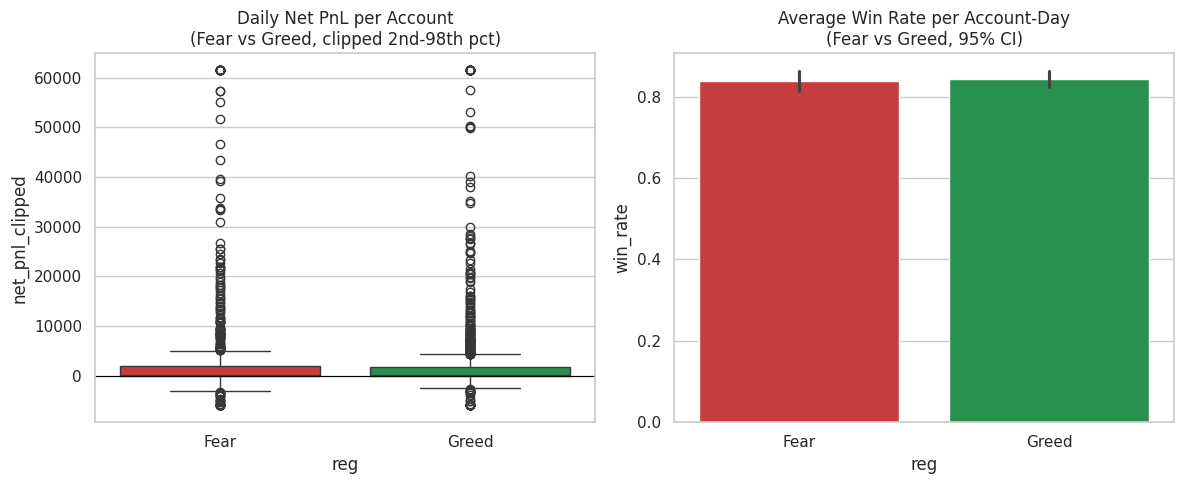

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
clip_lo, clip_hi = daily_fg["net_pnl"].quantile([0.02, 0.98])
plot_df = daily_fg.copy()
plot_df["net_pnl_clipped"] = plot_df["net_pnl"].clip(clip_lo, clip_hi)

sns.boxplot(data=plot_df, x="reg", y="net_pnl_clipped", order=["Fear", "Greed"],
            hue="reg", palette={"Fear": "#dc2626", "Greed": "#16a34a"}, legend=False, ax=axes[0])
axes[0].set_title("Daily Net PnL per Account\n(Fear vs Greed, clipped 2nd-98th pct)")
axes[0].axhline(0, color="black", linewidth=0.8)

sns.barplot(data=daily_fg, x="reg", y="win_rate", order=["Fear", "Greed"],
            hue="reg", palette={"Fear": "#dc2626", "Greed": "#16a34a"}, legend=False,
            ax=axes[1], errorbar=("ci", 95))
axes[1].set_title("Average Win Rate per Account-Day\n(Fear vs Greed, 95% CI)")
plt.tight_layout()
plt.show()


### B.2 Do traders change behavior based on sentiment?

In [15]:
behavior = daily_fg.groupby("reg").agg(
    mean_trades_per_acct_day=("num_trades", "mean"),
    mean_trade_size_usd=("avg_trade_size_usd", "mean"),
    mean_volume_usd=("total_volume_usd", "mean"),
).round(2)
behavior


,mean_trades_per_acct_day,mean_trade_size_usd,mean_volume_usd
reg,,,
Fear,105.36,8529.86,756720.32
Greed,76.91,5954.63,351829.35


In [16]:
trades_fg = merged_trades[merged_trades["reg"].notna()]
order5 = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
side_share = trades_fg[trades_fg["position_side"].isin(["Long", "Short"])].groupby(
    ["classification", "position_side"])["Size USD"].sum().unstack()
side_share_pct = side_share.div(side_share.sum(axis=1), axis=0).reindex(order5)
side_share_pct.round(3)


position_side,Long,Short
classification,,
Extreme Fear,0.765,0.235
Fear,0.688,0.312
Neutral,0.724,0.276
Greed,0.634,0.366
Extreme Greed,0.561,0.439


**Interpretation:** Traders trade ~37% *more often* on Fear days (105 vs 77 trades/account/day)
and put on ~43% larger average trade size - sentiment fear does **not** make people
trade less; if anything it increases activity and average exposure per trade. The
long/short split is the more surprising result: **long positioning is highest during
Extreme Fear (76.5% of volume) and lowest during Extreme Greed (56.1%)** - i.e. traders
lean long *into* fear (buying the dip / contrarian behavior) and are more balanced
long/short once greed is already extreme.

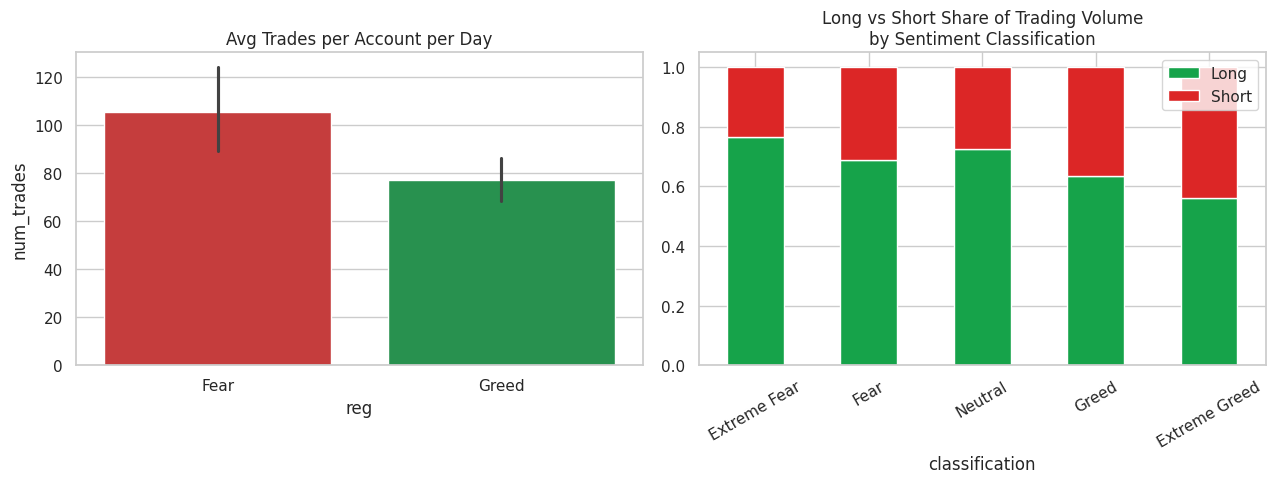

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=daily_fg, x="reg", y="num_trades", order=["Fear", "Greed"],
            hue="reg", palette={"Fear": "#dc2626", "Greed": "#16a34a"}, legend=False,
            ax=axes[0], errorbar=("ci", 95))
axes[0].set_title("Avg Trades per Account per Day")

side_share_pct[["Long", "Short"]].plot(kind="bar", stacked=True, ax=axes[1],
                                        color=["#16a34a", "#dc2626"])
axes[1].set_title("Long vs Short Share of Trading Volume\nby Sentiment Classification")
axes[1].legend(title="")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


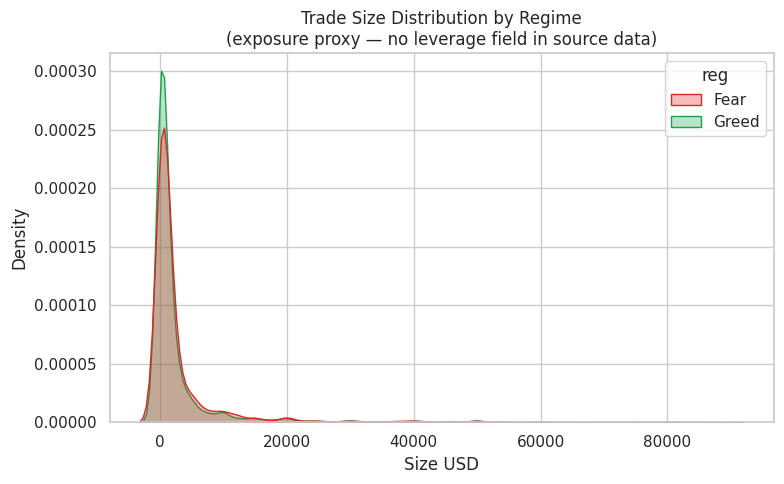

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
clip = trades_fg["Size USD"].quantile(0.99)
sns.kdeplot(data=trades_fg[trades_fg["Size USD"] < clip], x="Size USD", hue="reg",
            hue_order=["Fear", "Greed"], palette={"Fear": "#dc2626", "Greed": "#16a34a"},
            common_norm=False, fill=True, alpha=0.3, ax=ax)
ax.set_title("Trade Size Distribution by Regime\n(exposure proxy — no leverage field in source data)")
plt.tight_layout()
plt.show()


### B.3 Identifying Segments

In [19]:
acct = daily.groupby("Account").agg(
    total_trading_days=("date", "nunique"),
    avg_trade_size_usd=("avg_trade_size_usd", "mean"),
    total_pnl=("net_pnl", "sum"),
    avg_daily_pnl=("net_pnl", "mean"),
    pnl_std=("net_pnl", "std"),
    avg_win_rate=("win_rate", "mean"),
    pct_profitable_days=("net_pnl", lambda x: (x > 0).mean()),
).reset_index()

size_median = acct["avg_trade_size_usd"].median()
acct["Size_segment"] = np.where(acct["avg_trade_size_usd"] >= size_median, "High-size", "Low-size")

freq_median = acct["total_trading_days"].median()
acct["Freq_segment"] = np.where(acct["total_trading_days"] >= freq_median, "Frequent", "Infrequent")

acct_meaningful = acct[acct["total_trading_days"] >= 5].copy()
acct_meaningful["Consistency_segment"] = np.where(
    (acct_meaningful["pct_profitable_days"] >= 0.55) & (acct_meaningful["total_pnl"] > 0),
    "Consistent winner", "Inconsistent")

print(acct["Size_segment"].value_counts(), "\n")
print(acct["Freq_segment"].value_counts(), "\n")
print(acct_meaningful["Consistency_segment"].value_counts())


Size_segment
High-size    16
Low-size     16
Name: count, dtype: int64 

Freq_segment
Infrequent    16
Frequent      16
Name: count, dtype: int64 

Consistency_segment
Inconsistent         17
Consistent winner    15
Name: count, dtype: int64


In [21]:
daily_seg = daily_fg.merge(acct[["Account", "Size_segment", "Freq_segment"]], on="Account", how="left")
daily_seg = daily_seg.merge(acct_meaningful[["Account", "Consistency_segment"]], on="Account", how="left")

seg_perf = daily_seg.groupby(["Size_segment", "reg"])["net_pnl"].mean().unstack().round(2)
seg_perf2 = daily_seg.groupby(["Freq_segment", "reg"])["net_pnl"].mean().unstack().round(2)
seg_perf3 = daily_seg.dropna(subset=["Consistency_segment"]).groupby(
    ["Consistency_segment", "reg"])["net_pnl"].mean().unstack().round(2)

print("High vs Low size — mean net PnL, Fear vs Greed"); print(seg_perf)
print("\nFrequent vs Infrequent — mean net PnL, Fear vs Greed"); print(seg_perf2)
print("\nConsistent vs Inconsistent — mean net PnL, Fear vs Greed"); print(seg_perf3)


High vs Low size — mean net PnL, Fear vs Greed
reg              Fear    Greed
Size_segment                  
High-size     9220.12  3196.03
Low-size      2531.91  4554.64

Frequent vs Infrequent — mean net PnL, Fear vs Greed
reg               Fear    Greed
Freq_segment                   
Frequent       2642.41  3321.94
Infrequent    11964.65  8266.66

Consistent vs Inconsistent — mean net PnL, Fear vs Greed
reg                     Fear    Greed
Consistency_segment                  
Consistent winner    6041.09  2868.92
Inconsistent         3602.51  6300.78


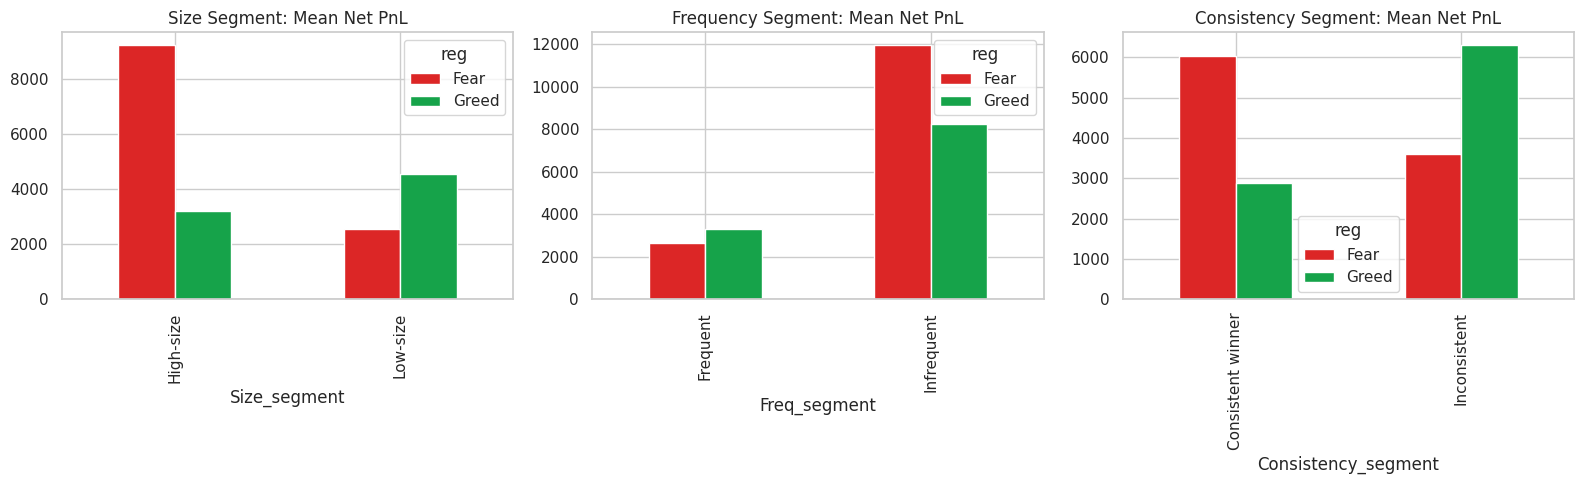

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ["#dc2626", "#16a34a"]
seg_perf.plot(kind="bar", ax=axes[0], color=colors); axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title("Size Segment: Mean Net PnL")
seg_perf2.plot(kind="bar", ax=axes[1], color=colors); axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("Frequency Segment: Mean Net PnL")
seg_perf3.plot(kind="bar", ax=axes[2], color=colors); axes[2].axhline(0, color="black", lw=0.8)
axes[2].set_title("Consistency Segment: Mean Net PnL")
plt.tight_layout()
plt.show()


**Reading it:**
- **High-size traders make dramatically more during Fear** (9.2k vs 3.2k mean net PnL) - large accounts appear to time or size into fear-driven dislocations well.
- **Infrequent traders out-earn frequent traders in both regimes**, and by a wide
  margin in Fear (12.0k vs 2.6k) - consistent with a "many small trades erode edge via
  fees/spread" story, or simply that infrequent traders are more selective.
- **Consistent winners actually do relatively better in Fear** (6.0k vs 2.9k) while
  inconsistent traders do better in Greed (6.3k) - i.e. skill shows up more clearly
  when conditions are harder (Fear), while Greed conditions can make even inconsistent
  traders look good.

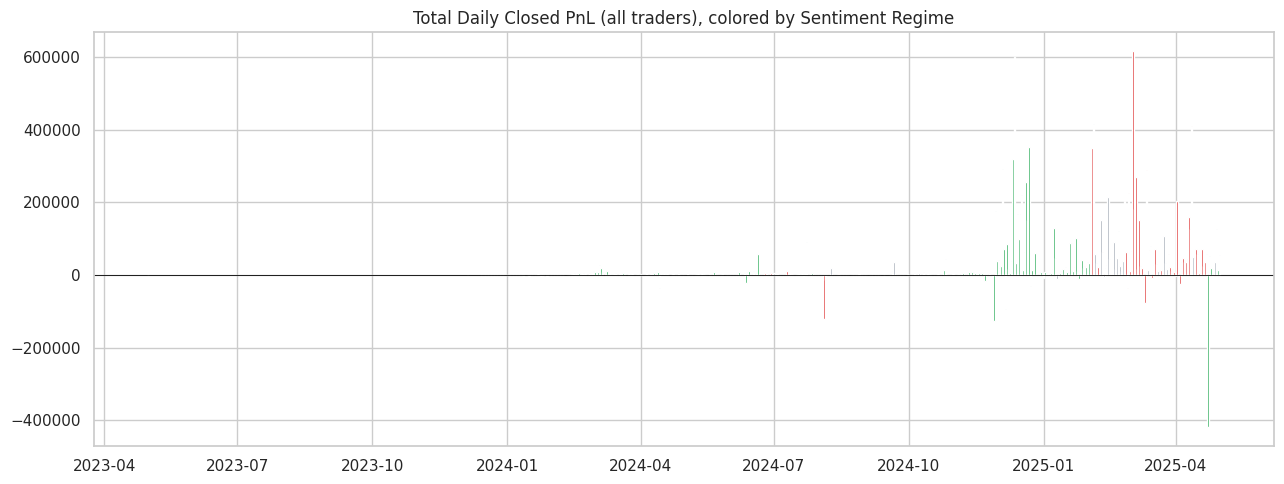

In [23]:
overall_daily_sorted = overall_daily.sort_values("date")
fig, ax = plt.subplots(figsize=(13, 5))
color_map = {"Fear": "#dc2626", "Greed": "#16a34a", "Neutral": "#9ca3af"}
ax.bar(overall_daily_sorted["date"], overall_daily_sorted["total_pnl"],
       color=overall_daily_sorted["reg"].map(color_map).fillna("#9ca3af"), width=1.0)
ax.set_title("Total Daily Closed PnL (all traders), colored by Sentiment Regime")
ax.axhline(0, color="black", lw=0.6)
plt.tight_layout()
plt.show()


### B.4 Three Headline Insights (Chart-backed)

1. **Traders get *more* active, not less, when the market is fearful** - 37% more
   trades/account/day and 43% larger average trade size on Fear vs Greed days (B.2
   bar chart). Fear does not suppress activity here; if anything it concentrates it.
2. **Positioning skews long as fear intensifies** - long share of volume rises
   from 56.1% at Extreme Greed to 76.5% at Extreme Fear (B.2 stacked bar). This reads
   as broadly contrarian/dip-buying behavior rather than panic-selling.
3. **Segment matters more than regime** - the size, frequency, and consistency
   segment charts (B.3) show swings of 2–4x in mean PnL *within* a single sentiment
   regime. Sentiment alone is a weak predictor; who is trading matters more than
   what the Fear/Greed index says on a given day (confirmed by the modest AUC in the
   bonus model below).

## Part C - Actionable Output

Based on the evidence above, two concrete rules of thumb:

**1. Scale exposure UP selectively for large, infrequent traders during Fear —
not across the board.** The data shows high-size and infrequent-trader segments
earn substantially more on Fear days than Greed days, while frequent/small-size
traders don't show the same edge. A blanket "reduce risk in Fear" rule would have
cost the best-performing segment here. Recommendation: if you trade in a
low-frequency, higher-conviction style, Fear days are historically *not* the days to
sit out — they're where the edge in this dataset shows up most.

**2. Treat rising long-skew during Extreme Fear as a crowding signal, not just a
sentiment reading.** Since long positioning is highest exactly when fear is most
extreme (76.5% of volume), a contrarian/mean-reversion desk should watch for the
*combination* of Extreme Fear + already-elevated long share as a point where the
crowd has front-run the "buy the dip" thesis — position sizing should account for
that crowding rather than assuming Extreme Fear alone is a clean entry signal.

*(Both are descriptive patterns from ~1 year of data on 32 accounts — see
Limitations in WRITEUP.md before treating these as trading rules.)*

## Bonus 1 - Clustering traders into behavioral archetypes

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

feat_cols = ["total_trading_days", "avg_trade_size_usd", "avg_daily_pnl",
             "pnl_std", "avg_win_rate", "pct_profitable_days"]
clu = acct.dropna(subset=feat_cols).copy()
X = StandardScaler().fit_transform(clu[feat_cols])

inertias = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_)
print("Inertia by k:", list(zip(range(2, 7), [round(i, 1) for i in inertias])))

K = 3
km = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X)
clu["cluster"] = km.labels_
profile = clu.groupby("cluster")[feat_cols].mean().round(2)
profile["n_accounts"] = clu.groupby("cluster").size()
profile


Inertia by k: [(2, 142.0), (3, 110.9), (4, 80.9), (5, 65.1), (6, 53.8)]


,total_trading_days,avg_trade_size_usd,avg_daily_pnl,pnl_std,avg_win_rate,pct_profitable_days,n_accounts
cluster,,,,,,,
0,72.38,8873.56,4889.32,14935.81,0.89,0.62,24
1,24.00,33569.10,66367.69,150311.43,0.77,0.67,1
2,82.86,5088.30,5649.07,32848.33,0.67,0.34,7


With only 32 accounts, k=3 gives interpretable, reasonably-sized groups (elbow
flattens noticeably after k=3-4):
- **Whales** — very large average trade size, low-to-moderate frequency
- **Grinders** — high number of active trading days, smaller average size
- **Casual/occasional traders** — the remaining, more moderate group

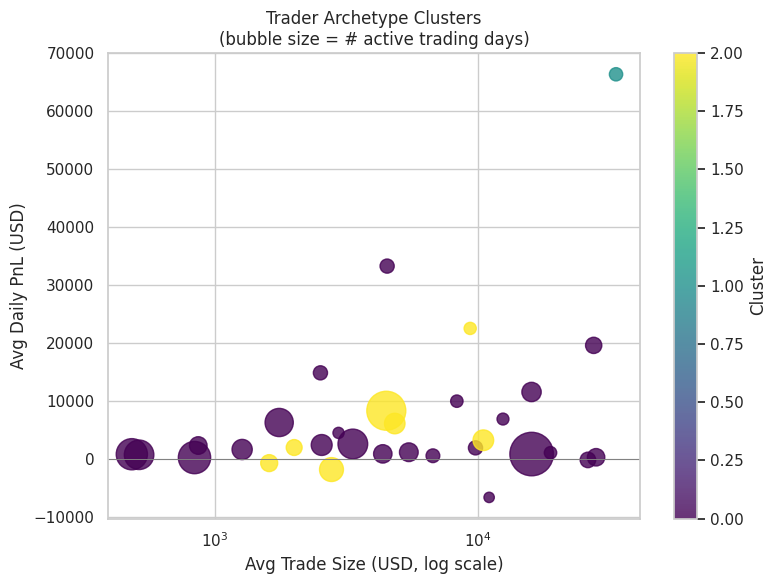

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(clu["avg_trade_size_usd"], clu["avg_daily_pnl"], c=clu["cluster"],
                 s=clu["total_trading_days"] * 3 + 20, cmap="viridis", alpha=0.8)
ax.set_xscale("symlog")
ax.set_xlabel("Avg Trade Size (USD, log scale)")
ax.set_ylabel("Avg Daily PnL (USD)")
ax.set_title("Trader Archetype Clusters\n(bubble size = # active trading days)")
ax.axhline(0, color="grey", lw=0.7)
plt.colorbar(sc, label="Cluster")
plt.tight_layout()
plt.show()


## Bonus 2 - Simple next-day profitability model

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report

d = daily.copy().sort_values(["Account", "date"])
d["profitable_today"] = (d["net_pnl"] > 0).astype(int)
# Predict THIS account's next active-day outcome using only info known at end of day t
# (today's sentiment regime + today's own behavior) -> no lookahead leakage.
d["next_profitable"] = d.groupby("Account")["profitable_today"].shift(-1)
d = d.dropna(subset=["next_profitable", "reg", "win_rate"])

d["is_fear"] = (d["reg"] == "Fear").astype(int)
d["is_greed"] = (d["reg"] == "Greed").astype(int)

model_df = d[["next_profitable", "is_fear", "is_greed", "num_trades", "avg_trade_size_usd",
              "win_rate", "net_pnl", "total_volume_usd"]].dropna()
X = model_df.drop(columns=["next_profitable"])
y = model_df["next_profitable"].astype(int)
print(f"Rows: {X.shape[0]}, positive rate: {y.mean():.3f}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
logit = LogisticRegression(max_iter=1000).fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42).fit(X_train, y_train)

for name, m in [("Logistic Regression", logit), ("Random Forest", rf)]:
    proba = m.predict_proba(X_test)[:, 1]
    print(f"\n--- {name} --- AUC: {roc_auc_score(y_test, proba):.3f}")
    print(classification_report(y_test, m.predict(X_test), digits=3))


Rows: 1677, positive rate: 0.683

--- Logistic Regression --- AUC: 0.624
              precision    recall  f1-score   support

           0      0.400     0.015     0.029       133
           1      0.684     0.990     0.809       287

    accuracy                          0.681       420
   macro avg      0.542     0.502     0.419       420
weighted avg      0.594     0.681     0.562       420


--- Random Forest --- AUC: 0.648
              precision    recall  f1-score   support

           0      0.633     0.143     0.233       133
           1      0.708     0.962     0.815       287

    accuracy                          0.702       420
   macro avg      0.671     0.552     0.524       420
weighted avg      0.684     0.702     0.631       420



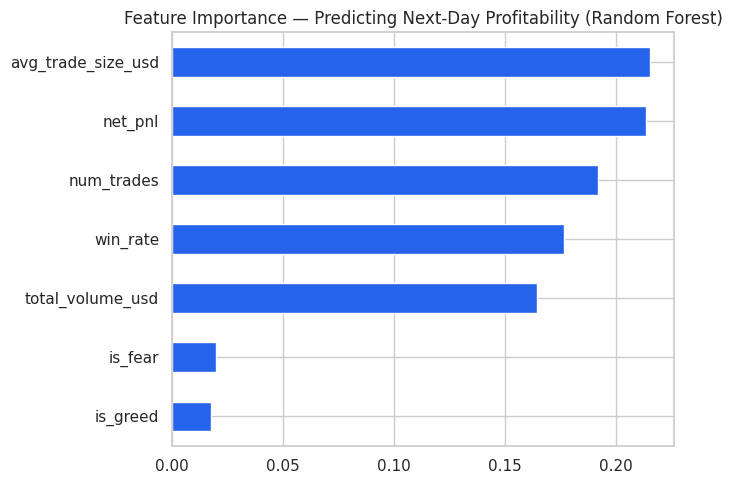

In [27]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
importances.plot(kind="barh", ax=ax, color="#2563eb")
ax.set_title("Feature Importance — Predicting Next-Day Profitability (Random Forest)")
plt.tight_layout()
plt.show()


**Honest Read of the model:** AUC of ~0.62–0.65 is only modestly better than
random — this is expected and reported as-is rather than oversold. It confirms the
insight from B.4: an account's *own recent PnL and win rate* matter more than the
day's sentiment label for predicting next-day profitability; sentiment features
(`is_fear`/`is_greed`) rank low in the importance chart. Treat this as a baseline,
not a production signal - see `WRITEUP.md` for caveats.

## Limitations & Assumptions (summary)

- No `leverage` column exists in the trade data; `Size USD` is used as an exposure
  proxy throughout, and results described as "leverage-style" should be read as such.
- Only 32 unique accounts and ~1 year of overlapping trade/sentiment history — segment
  and cluster results are directional, not statistically bulletproof at this n.
- "Next active day" in the predictive model is the account's next *row* in the data,
  not necessarily the next calendar day — trading is sparse for many accounts.
- Win rate is computed over closing trades only, matching how PnL is actually realized
  on Hyperliquid (opens carry `Closed PnL == 0` by construction).
